In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
columns = [
  'checking_status', 'duration', 'credit_history', 'purpose', 
  'credit_amount', 'savings_status', 'employment', 'installment_rate',
  'personal_status', 'other_parties', 'residence_since', 'property',
  'age', 'other_payment_plans', 'housing', 'existing_credits',
  'job', 'num_dependents', 'telephone', 'foreign_worker', 'class'
]

df = pd.read_csv('../data/raw/german.data', sep=' ', header=None, names=columns)
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property,age,other_payment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [4]:
print(df.shape)

print(df['class'].value_counts())

print(df.dtypes)

print(df.isnull().sum())

(1000, 21)
class
1    700
2    300
Name: count, dtype: int64
checking_status          str
duration               int64
credit_history           str
purpose                  str
credit_amount          int64
savings_status           str
employment               str
installment_rate       int64
personal_status          str
other_parties            str
residence_since        int64
property                 str
age                    int64
other_payment_plans      str
housing                  str
existing_credits       int64
job                      str
num_dependents         int64
telephone                str
foreign_worker           str
class                  int64
dtype: object
checking_status        0
duration               0
credit_history         0
purpose                0
credit_amount          0
savings_status         0
employment             0
installment_rate       0
personal_status        0
other_parties          0
residence_since        0
property               0
age             

In [5]:
numeric_cols = df.select_dtypes(include=['int64']).columns.drop('class')
df[numeric_cols].describe()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


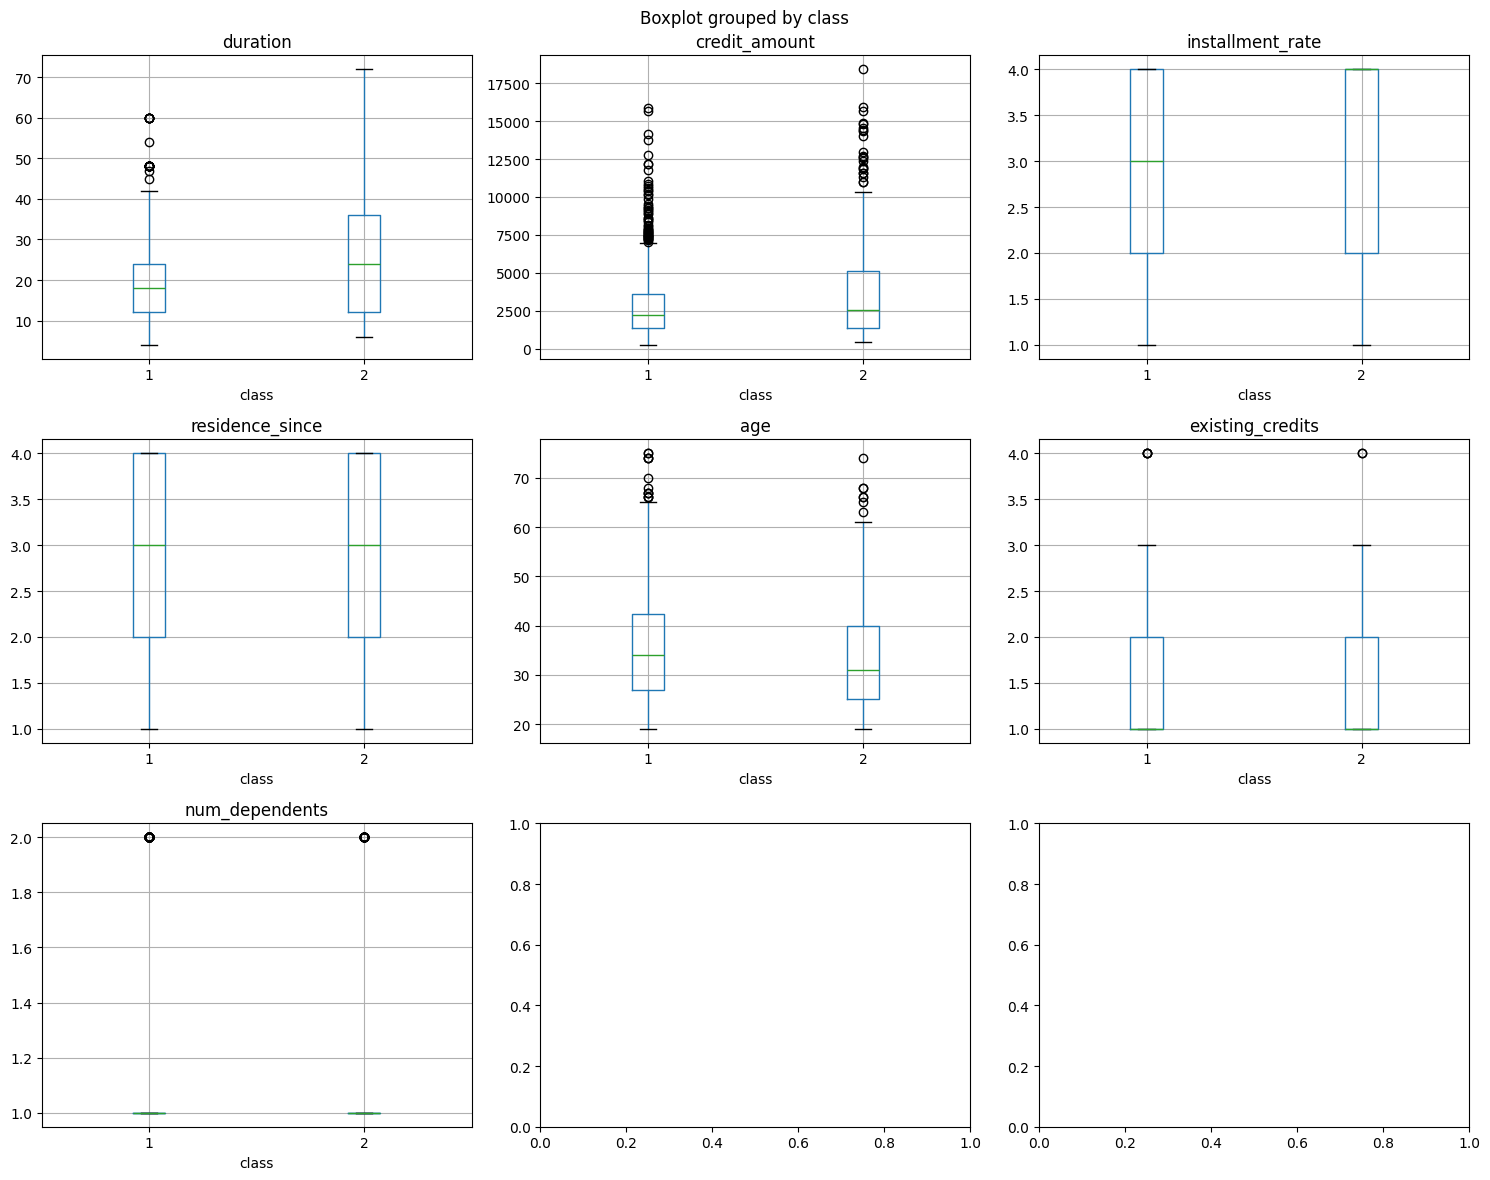

In [6]:
# Outliers (boxplots)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for id, col in enumerate(numeric_cols):
  ax = axes[id//3, id%3]
  df.boxplot(column=col, by='class', ax=ax)
plt.tight_layout()
plt.show()

In [7]:
categorical_cols = df.select_dtypes(include=['str']).columns
for col in categorical_cols:
 print(f"{col}: {df[col].nunique()} unique values")
 print(df[col].value_counts())
 print()

checking_status: 4 unique values
checking_status
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64

credit_history: 5 unique values
credit_history
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64

purpose: 10 unique values
purpose
A43     280
A40     234
A42     181
A41     103
A49      97
A46      50
A45      22
A44      12
A410     12
A48       9
Name: count, dtype: int64

savings_status: 5 unique values
savings_status
A61    603
A65    183
A62    103
A63     63
A64     48
Name: count, dtype: int64

employment: 5 unique values
employment
A73    339
A75    253
A74    174
A72    172
A71     62
Name: count, dtype: int64

personal_status: 4 unique values
personal_status
A93    548
A92    310
A94     92
A91     50
Name: count, dtype: int64

other_parties: 3 unique values
other_parties
A101    907
A103     52
A102     41
Name: count, dtype: int64

property: 4 unique values
property
A123    332
A121    282
A122    232
A124    154
Name: cou

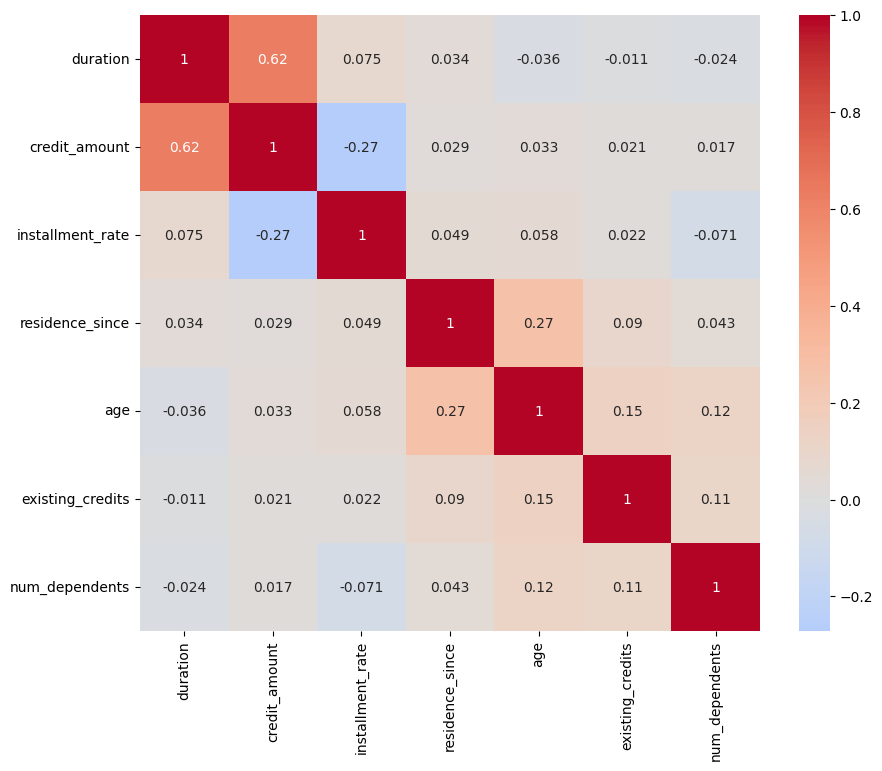

In [8]:
# Correlation heatmap
correlation = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.show()

In [9]:
print(pd.crosstab(df['checking_status'], df['class'], normalize='index'))

print(pd.crosstab(df['credit_history'], df['class'], normalize='index'))

print(pd.crosstab(df['purpose'], df['class'], normalize='index'))

class                   1         2
checking_status                    
A11              0.507299  0.492701
A12              0.609665  0.390335
A13              0.777778  0.222222
A14              0.883249  0.116751
class                  1         2
credit_history                    
A30             0.375000  0.625000
A31             0.428571  0.571429
A32             0.681132  0.318868
A33             0.681818  0.318182
A34             0.829352  0.170648
class           1         2
purpose                    
A40      0.619658  0.380342
A41      0.834951  0.165049
A410     0.583333  0.416667
A42      0.679558  0.320442
A43      0.778571  0.221429
A44      0.666667  0.333333
A45      0.636364  0.363636
A46      0.560000  0.440000
A48      0.888889  0.111111
A49      0.649485  0.350515


In [10]:
# Savings status
print(pd.crosstab(df['savings_status'], df['class'], normalize='index'))

# Employment status
print(pd.crosstab(df['employment'], df['class'], normalize='index'))

# Personal status (marital + gender)
print(pd.crosstab(df['personal_status'], df['class'], normalize='index'))

class                  1         2
savings_status                    
A61             0.640133  0.359867
A62             0.669903  0.330097
A63             0.825397  0.174603
A64             0.875000  0.125000
A65             0.825137  0.174863
class              1         2
employment                    
A71         0.629032  0.370968
A72         0.593023  0.406977
A73         0.693215  0.306785
A74         0.775862  0.224138
A75         0.747036  0.252964
class                   1         2
personal_status                    
A91              0.600000  0.400000
A92              0.648387  0.351613
A93              0.733577  0.266423
A94              0.728261  0.271739
